🚀 Steps to Do Before Training LSTM
1️⃣ Load the Data

Read the dataset (pd.read_csv()).
Check missing values and data types (df.dtypes).
2️⃣ Fix the Data

Convert Date and Time into one column (pd.to_datetime()).
Handle missing values (df.fillna(method='ffill')).
3️⃣ Normalize the Data

Scale values between 0 and 1 using MinMaxScaler().
4️⃣ Split Data

80% for training, 20% for testing.
5️⃣ Make Sequences

Use past 60 time steps to predict the next one (create_sequences()).
Reshape data for LSTM (X_train.reshape(samples, time_steps, 1)).


In [1]:
# Building an RNN for Time Series Prediction Using GRU and LSTM
# Setting Up the Environment
# We start by importing the necessary libraries and setting up the environment for our project.

# Importing the libraries
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import Dense, LSTM, Dropout, GRU
from keras.optimizers import SGD
import math
from sklearn.metrics import mean_squared_error


In [2]:
from google.colab import files
uploaded = files.upload()

Saving AABA_2006-01-01_to_2018-01-01.csv to AABA_2006-01-01_to_2018-01-01.csv


In [3]:
dataset = pd.read_csv('AABA_2006-01-01_to_2018-01-01.csv')
dataset.head()

,Date,Open,High,Low,Close,Volume,Name
0,2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
1,2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2,2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
3,2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
4,2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [5]:
# 5. Model Evaluation

# mean_squared_error: Measures the difference between predicted and actual values.
# Some functions to help out with

def plot_predictions(test,predicted):
    plt.plot(test, color='red',label='Real IBM Stock Price')
    plt.plot(predicted, color='blue',label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

def return_rmse(test,predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

In [7]:
# Loading and Preprocessing the Data
# We will use IBM stock price data from 2006 to 2018, download it. The dataset contains daily stock prices, and we will use the “High” attribute for our predictions.

# Load the dataset
dataset = pd.read_csv('AABA_2006-01-01_to_2018-01-01.csv', index_col='Date', parse_dates=['Date'])
dataset.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


In [8]:
# Splitting the Data
# We split the data into a training set (before 2017) and a test set (2017 and beyond).

# Splitting the data into training and test sets
training_set = dataset[:'2016'].iloc[:, 1:2].values  # Using the 'High' column
test_set = dataset['2017':].iloc[:, 1:2].values

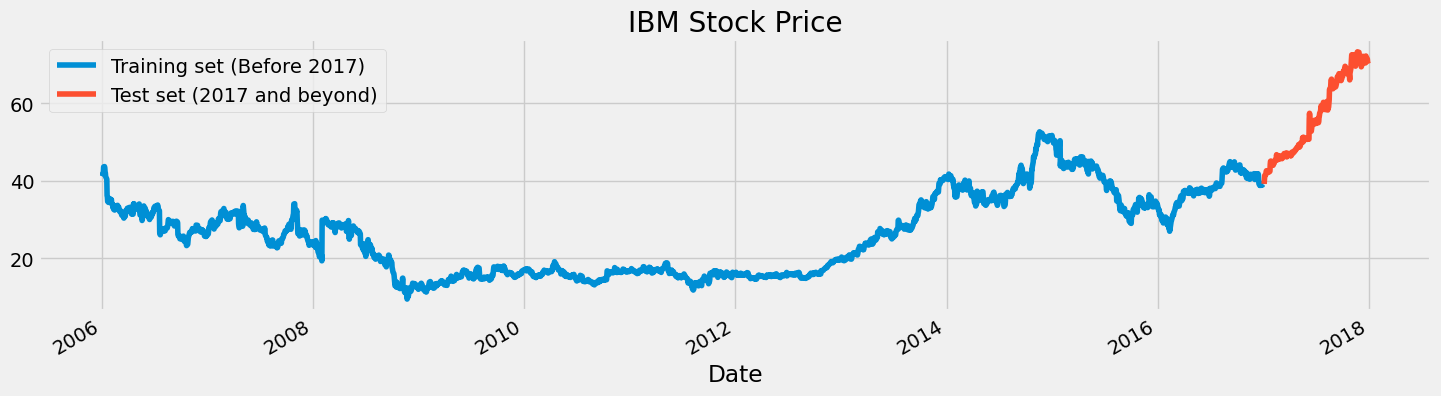

In [13]:
# Plotting the training and test sets
dataset["High"][:'2016'].plot(figsize=(16, 4), legend=True)
dataset["High"]['2017':].plot(figsize=(16, 4), legend=True)
plt.legend(['Training set (Before 2017)', 'Test set (2017 and beyond)'])
plt.title('IBM Stock Price')
plt.show()

In [9]:
# Checking for missing values

training_set = dataset[:'2016'].iloc[:,1:2].values
test_set = dataset['2017':].iloc[:,1:2].values

In [11]:
# Scaling the Data
# NORMALIZATION
# We scale the data to a range of [0, 1] to improve the performance of the RNN.

# Scaling the training set
sc = MinMaxScaler(feature_range=(0, 1))
training_set_scaled = sc.fit_transform(training_set)

In [15]:
# Preparing the Data for RNNs
# RNNs require sequential data. We create a data structure with 60 timesteps and 1 output. For each element of the training set, we use the previous 60 timesteps to predict the next value.

# Creating the data structure with 60 timesteps
X_train = []
y_train = []
for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshaping X_train for efficient modeling
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [16]:
# reshape the data

X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [17]:
# Building and Training the LSTM Model
# We will now build an LSTM model with four LSTM layers and dropout regularization to prevent overfitting.

# Building the LSTM model
regressor = Sequential()

# First LSTM layer with Dropout regularization
regressor.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)))
regressor.add(Dropout(0.2))

# Second LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Third LSTM layer
regressor.add(LSTM(units=50, return_sequences=True))
regressor.add(Dropout(0.2))

# Fourth LSTM layer
regressor.add(LSTM(units=50))
regressor.add(Dropout(0.2))

# Output layer
regressor.add(Dense(units=1))

# Compiling the model
regressor.compile(optimizer='rmsprop', loss='mean_squared_error')

# Training the model
regressor.fit(X_train, y_train, epochs=50, batch_size=32)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 16s 111ms/step - loss: 0.0361
Epoch 2/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.0076
Epoch 3/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 117ms/step - loss: 0.0060
Epoch 4/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 100ms/step - loss: 0.0056
Epoch 5/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step - loss: 0.0042
Epoch 6/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0041
Epoch 7/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0038
Epoch 8/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0033
Epoch 9/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 98ms/step - loss: 0.0028
Epoch 10/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 102ms/step - loss: 0.0029
Epoch 11/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step - loss: 0.0030
Epoch 12/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 111ms/step - loss: 0.0028
Epoch 13/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.0026
Epoch 14/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 8s 99ms/step - loss: 0.0024
Epoch 15/50
85/85 ━━━━━━━━━━━━━━━━━━━━ 11s 103ms/ste

In [20]:
# Making Predictions with the LSTM Model
# After training the model, we use it to predict the stock prices for the test set.

# Preparing the test set
dataset_total = pd.concat((dataset["High"][:'2016'], dataset["High"]['2017':]), axis=0)
inputs = dataset_total[len(dataset_total) - len(test_set) - 60:].values
inputs = inputs.reshape(-1, 1)
inputs = sc.transform(inputs)

# Preparing X_test
X_test = []
for i in range(60, 311):
    X_test.append(inputs[i-60:i, 0])
X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

# Making predictions
predicted_stock_price = regressor.predict(X_test)
predicted_stock_price = sc.inverse_transform(predicted_stock_price)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 112ms/step


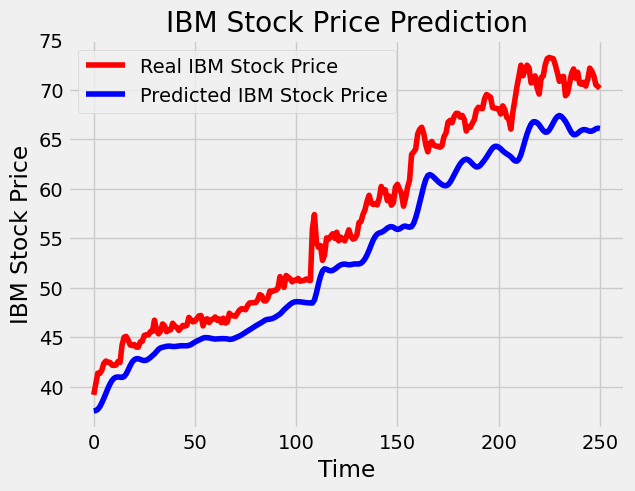

In [22]:
# Visualizing the Results
# We plot the predicted stock prices against the actual stock prices.

# Plotting the results
def plot_predictions(test, predicted):
    plt.plot(test, color='red', label='Real IBM Stock Price')
    plt.plot(predicted, color='blue', label='Predicted IBM Stock Price')
    plt.title('IBM Stock Price Prediction')
    plt.xlabel('Time')
    plt.ylabel('IBM Stock Price')
    plt.legend()
    plt.show()

plot_predictions(test_set, predicted_stock_price)

In [23]:
# Evaluating the Model
# We calculate the Root Mean Squared Error (RMSE) to evaluate the model’s performance.
# Why Use RMSE? It measures the average magnitude of the error between predicted and actual values. It is useful because:

# It penalizes larger errors more heavily, making it sensitive to major deviations.
# It provides an intuitive measure of how far predictions are from actual values.
# Lower RMSE values indicate better model accuracy.

# Calculating RMSE
def return_rmse(test, predicted):
    rmse = math.sqrt(mean_squared_error(test, predicted))
    print("The root mean squared error is {}.".format(rmse))

return_rmse(test_set, predicted_stock_price)

The root mean squared error is 3.9895417705287546.


In [25]:
# Building and Training the GRU Model
# Next, we build a GRU model with four GRU layers and dropout regularization.

# Building the GRU model
regressorGRU = Sequential()

# First GRU layer with Dropout regularization
regressorGRU.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1), activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Second GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Third GRU layer
regressorGRU.add(GRU(units=50, return_sequences=True, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Fourth GRU layer
regressorGRU.add(GRU(units=50, activation='tanh'))
regressorGRU.add(Dropout(0.2))

# Output layer
regressorGRU.add(Dense(units=1))

# Compiling the model
regressorGRU.compile(optimizer=SGD(learning_rate=0.01, decay=1e-7, momentum=0.9, nesterov=False), loss='mean_squared_error')

# Training the model
regressorGRU.fit(X_train, y_train, epochs=50, batch_size=150)

Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:86: UserWarning: Argument `decay` is no longer supported and will be ignored.
  warnings.warn(


19/19 ━━━━━━━━━━━━━━━━━━━━ 14s 320ms/step - loss: 0.1159
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 313ms/step - loss: 0.0438
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 319ms/step - loss: 0.0173
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - loss: 0.0051
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 313ms/step - loss: 0.0034
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 280ms/step - loss: 0.0030
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 5s 276ms/step - loss: 0.0034
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 11s 314ms/step - loss: 0.0026
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 296ms/step - loss: 0.0027
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 247ms/step - loss: 0.0025
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 318ms/step - loss: 0.0024
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 10s 308ms/step - loss: 0.0024
Epoch 13/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 253ms/step - loss: 0.0024
Epoch 14/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 7s 367ms/step - loss: 0.0023
Epoch 15/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 9s 311ms/step - loss: 

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 130ms/step


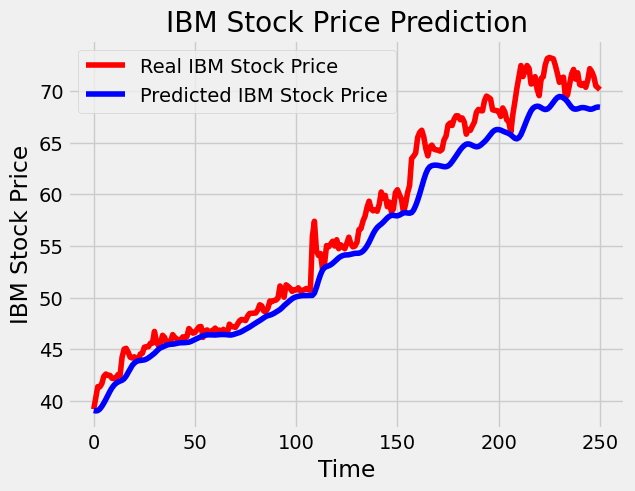

The root mean squared error is 2.3876921981975645.


In [26]:
# Making Predictions with the GRU Model
# We use the trained GRU model to predict the stock prices for the test set.

# Making predictions
GRU_predicted_stock_price = regressorGRU.predict(X_test)
GRU_predicted_stock_price = sc.inverse_transform(GRU_predicted_stock_price)

# Visualizing the results
plot_predictions(test_set, GRU_predicted_stock_price)

# Evaluating the model
return_rmse(test_set, GRU_predicted_stock_price)

In [27]:
# Sequence Generation
# To further test the models, we generate a sequence of predictions using only the initial 60 values. This simulates a real-world scenario where we do not have access to future stock prices, and we must predict iteratively.
# This simulates a real-world scenario where we don’t have access to future data.

# Preparing sequence data
initial_sequence = X_train[2708, :]
sequence = []
for i in range(251):
    new_prediction = regressorGRU.predict(initial_sequence.reshape(1, initial_sequence.shape[0], 1))
    initial_sequence = initial_sequence[1:]
    initial_sequence = np.append(initial_sequence, new_prediction, axis=0)
    sequence.append(new_prediction)
sequence = sc.inverse_transform(np.array(sequence).reshape(251, 1))

# Visualizing the sequence
plot_predictions(test_set, sequence)

# Evaluating the sequence

IndexError: index 2708 is out of bounds for axis 0 with size 2708